### Language Engineering Profile
#### GE - Grammar Engineering (2025/26)
##### Trabalho Prático 2 (TP2)

Static Source Code Analyzer
As we have seen in TP1, there are many types of static source code analysis
techniques, each with different goals and challenges, and that provide feedback
about source code. The goal of TP2 is to implement one such technique for a
simple imperative programming language (IPL), ideally the static analysis technique that the group has studied in TP1.
Specifically, the students should follow the following steps in the development
of the project:

#### Static Source Code Analyzer
As we have seen in TP1, there are many types of static source code analysis
techniques, each with different goals and challenges, and that provide feedback
about source code. The goal of TP2 is to implement one such technique for a
simple imperative programming language (IPL), ideally the static analysis technique that the group has studied in TP1.
Specifically, the students should follow the following steps in the development
of the project:

1. Design the IPL language and its grammar. The language should at least
allow the declaration of atomic and composed variables (e.g., lists, dictionaries or sets), conditional expressions, and different kinds of loop constructs (e.g., while or for loops);

In [ ]:
from lark import Lark, Transformer

grammar = r"""
start : block

block : (stm)*

?stm : decl ";"
    | expr ";"
    | ifexpr
    | whilexpr
    | forexpr
    | funcdef
    | funcall
    | BREAK
    | CONTINUE
    | printexpr ";"
    | input_call ";"
    | COMMENT

printexpr : "print" "(" args ")"

?input_call : READ "(" ")"
           | "let" NAME ASSIGN READ "("")"
           
?decl : "let" NAME ASSIGN expr
      | "let" NAME LBRACKET indices RBRACKET
      | "let" NAME LBRACE indices RBRACE
      | "let" NAME ASSIGN funcall

ifexpr : "if" expr "{" block "}" elsexpr?
elsexpr : "else" "{" block "}"

whilexpr : "while" expr "{" block "}"

forexpr : "for" expr "in" expr "{" block "}"

?expr : assign

?assign : cmp (ASSIGN cmp)*

?cmp : sum ((HIGHER | LOWER) sum)*

?sum : term ((MUL | DIV) term)*

?term : factor ((ADD | MINUS) factor)*

?factor : NUMBER
        | CONSTANT
        | NAME
        | "'"STRING"'"
        | list
        | dict
        | "(" expr ")"

funcall : NAME "("")"
        
funcdef : "func" NAME "("")" "{" block returnexpr "}"

returnexpr : "return" expr? ";"

?list : list_literal | list_comprehension

?list_literal : NAME LBRACKET indices RBRACKET
              | LBRACKET indices RBRACKET

?list_comprehension : NAME LBRACKET expr comp_for RBRACKET
                   | LBRACKET expr comp_for RBRACKET

comp_for : "for" NAME "in" expr comp_iter?
?comp_iter : comp_for | comp_if
comp_if : "if" expr comp_iter?

?dict : NAME LBRACE indices RBRACE
     | LBRACE indices RBRACE
     
?indices : index ("," index)* | 

?index : NAME | NUMBER 

?args : expr ("," expr)* | 

ASSIGN : "="
CONSTANT : "⊤" | "⊥"
HIGHER : ">"
LOWER : "<"
NAME : /[A-Za-z_][A-Za-z0-9_]*/
NUMBER : /[0-9]+(\.[0-9]+)?/
ADD : "+"
MINUS : "-"
MUL : "*"
DIV : "/"
RBRACKET : "]"
LBRACKET : "["
RBRACE : "}"
LBRACE : "{"
BREAK : "break"
CONTINUE : "continue"
STRING : /[A-Za-z_][A-Za-z0-9_]*/
READ : "read"
COMMENT : /\/\*(.|\n)*?\*\//

%ignore /[ \t]+/

%ignore /\n+/
"""

parser = Lark(grammar, start="start")

3. Use Lark to process the proposed IPL grammar and retrieve the abstract
syntax tree (AST) for IPL programs;

In [33]:
parser = Lark(grammar, start="start")

code = """
let r = [1,2,3];
let i = 0;
let a = read();


func fun1() {
    for t in r {
        print('r');
    }
    return i;
}

let x = fun1();
let lista = [i for i in ola];
"""

tree = parser.parse(code)
print(tree.pretty())

start
  block
    decl
      r
      =
      list_literal
        [
        indices
          1
          2
          3
        ]
    decl
      i
      =
      0
    decl
      a
      =
      funcall	read
    funcdef
      fun1
      block
        forexpr
          t
          r
          block
            printexpr	r
      returnexpr	i
    decl
      x
      =
      funcall	fun1
    decl
      lista
      =
      list_comprehension
        [
        i
        comp_for
          i
          ola
        ]



4. Use Lark visitor classes (either Visitor, Transformer or Interpreter)
to perform semantic elaboration of the AST. You should at least perform
(simple) scope analysis and type checking;

In [30]:
from lark.lexer import Token

class SemanticError(Exception):
    pass
class SemanticAnalyzer(Transformer):
    def __init__(self):
        self.scopes = [{}]

    def block(self, items):
        self.scopes.append({})
        self.scopes.pop()
        return items


    def decl(self, items):
        var_name = str(items[0])
        if any(var_name in scope for scope in reversed(self.scopes)):
            raise SemanticError(f"Erro: variável '{var_name}' já declarada neste escopo")
        else:
            self.scopes[-1][var_name] = None
        if len(items) > 1:
            self._check_expr(items[1])
        return items

    def printexpr(self, items):
        self._check_expr(items[0])
        return items

    def forexpr(self, items):
        self._check_expr(items[1])
        return items
    
    def whilexpr(self, items):
        self._check_expr(items[0])
        return items
    
    def assign(self, items):
        lhs = items[0]
        rhs_list = items[1:]

        lhs_name = str(lhs)
        if not any(lhs_name in scope for scope in reversed(self.scopes)):
            raise SemanticError(f"Variável '{lhs_name}' usada antes de ser declarada")
        for rhs in rhs_list:
            self._check_expr(rhs)
        return items
    
    def _check_expr(self, expr):
        if isinstance(expr, Token) and expr.type == "NAME":
            name = str(expr)
            if not any(name in scope for scope in reversed(self.scopes)):
                raise SemanticError(f"Variável '{name}' usada antes de ser declarada")
        elif hasattr(expr, "children"):
            for child in expr.children:
                self._check_expr(child)



In [36]:
code = """
let r = [1,2,3];
let i = 0;
let a = read();
b = 0;

func fun1() {
    if r > 0 {
        let y = 10;
    }
    
    return i;
}

let x = fun1();


let lista = [i for i in ola];
"""

tree = parser.parse(code)

try:
    SemanticAnalyzer().transform(tree)
    print("✔ Programa semanticamente correto")
except SemanticError as e:
    print("❌ Erro semântico:", e)




VisitError: Error trying to process rule "assign":

Variável 'b' usada antes de ser declarada

5. Use Lark visitor classes to extract intermediate representations from IPL
ASTs. You should at least extract the control flow graph (CFG);

In [39]:
import networkx as nx
from networkx.drawing.nx_pydot import to_pydot
from graphviz import Source

class CFGFragment:
    def __init__(self, entry, exit, graph=None):
        self.entry = entry
        self.exit = exit
        self.graph = graph or nx.DiGraph()

    def merge(self, other):
        self.graph.add_nodes_from(other.graph.nodes(data=True))
        self.graph.add_edges_from(other.graph.edges())
        self.graph.add_edge(self.exit, other.entry)
        self.exit = other.exit

class CFGTransformer(Transformer):

    def __init__(self):
        self.counter = 0

    def new_block(self, label):
        name = f"B{self.counter}"
        self.counter += 1
        g = nx.DiGraph()
        g.add_node(name, label=label)
        return CFGFragment(name, name, g)

    def start(self, items):
        return items[0]

    def block(self, items):
        if not items:
            return self.new_block("empty")
        frag = items[0]
        for f in items[1:]:
            frag.merge(f)
        return frag

    def decl(self, items):
        return self.new_block(f"let {items[0].value}")

    def expr(self, _):
        return self.new_block("expr...")
    
    def assign(self, items):
        return self.new_block("assign...")

    def cmp(self, items):
        return self.new_block("cmp...")

    def sum(self, items):
        return self.new_block("sum..")

    def term(self, items):
        return self.new_block("term...")

    def factor(self, items):
        return self._expr_str("factor...")

    def funcall(self, items):
        return self.new_block(f"call {items[0].value}")

    def printexpr(self, items):
        return self.new_block(f"print {items[0].value}")

    def input_call(self, _):
        return self.new_block("read")

    def BREAK(self, _):
        return self.new_block("break")

    def CONTINUE(self, _):
        return self.new_block("continue")

    def returnexpr(self, items):
        return self.new_block(f"return {items[0].value}")
    
    def ifexpr(self, items):
        cond = self.new_block("if")
        then_block = items[1]
        merge = self.new_block("merge_if")

        # then
        cond.graph.add_nodes_from(then_block.graph.nodes(data=True))
        cond.graph.add_edges_from(then_block.graph.edges())
        cond.graph.add_edge(cond.exit, then_block.entry)
        cond.graph.add_edge(then_block.exit, merge.entry)
        
        if items[2].children:
            else_block = items[2].children[0]
            cond.graph.add_nodes_from(else_block.graph.nodes(data=True))
            cond.graph.add_edges_from(else_block.graph.edges())
            cond.graph.add_edge(cond.exit, else_block.entry)
            cond.graph.add_edge(else_block.exit, merge.entry)
        
        else:
            cond.graph.add_edge(cond.exit, merge.entry)

        cond.graph.add_nodes_from(merge.graph.nodes(data=True))
        return CFGFragment(cond.entry, merge.exit, cond.graph)

    def whilexpr(self, items):
        cond = self.new_block("while")
        body = items[1]
        merge = self.new_block("merge_while")

        cond.graph.add_nodes_from(body.graph.nodes(data=True))
        cond.graph.add_edges_from(body.graph.edges())
        cond.graph.add_edge(cond.exit, body.entry)
        cond.graph.add_edge(body.exit, cond.entry)
        cond.graph.add_edge(cond.exit, merge.entry)

        cond.graph.add_nodes_from(merge.graph.nodes(data=True))
        return CFGFragment(cond.entry, merge.exit, cond.graph)

    def forexpr(self, items):
        start = self.new_block("for")
        body = items[2]
        merge = self.new_block("merge_for")

        start.graph.add_nodes_from(body.graph.nodes(data=True))
        start.graph.add_edges_from(body.graph.edges())
        start.graph.add_edge(start.exit, body.entry)

        start.graph.add_nodes_from(merge.graph.nodes(data=True))
        start.graph.add_edge(start.exit, merge.entry)
        start.graph.add_edge(body.exit, start.entry)
        return CFGFragment(start.entry, merge.exit, start.graph)

    def funcdef(self, items):
        entry = self.new_block(f"func {items[0].value}")
        body = items[1]
        ret = items[2]
        merge = self.new_block("merge_func")

        entry.graph.add_nodes_from(body.graph.nodes(data=True))
        entry.graph.add_edges_from(body.graph.edges())
        entry.graph.add_edge(entry.exit, body.entry)

        entry.graph.add_nodes_from(ret.graph.nodes(data=True))
        entry.graph.add_edge(body.exit, ret.entry)

        entry.graph.add_nodes_from(merge.graph.nodes(data=True))
        entry.graph.add_edge(ret.exit, merge.entry)

        return CFGFragment(entry.entry, merge.exit, entry.graph)



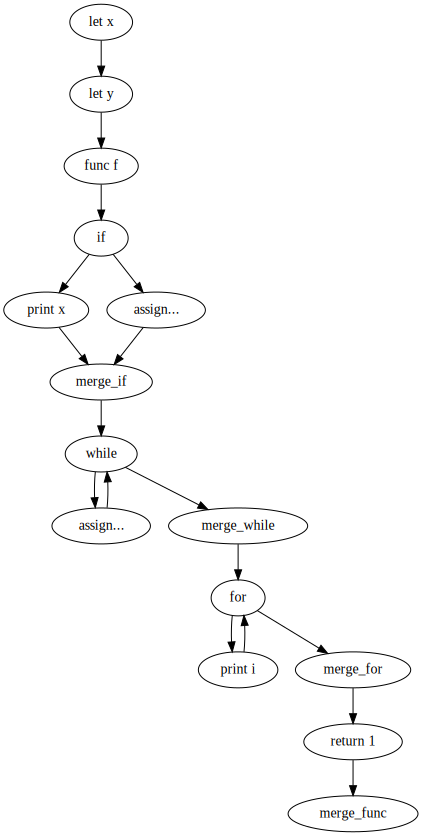

In [40]:
code = """
let x = 1;
let y = 2;

func f(){
    if x > 0 {
        print(x);
    } else {
        x = 1;
    }
    while x < 10 {
        x = x + 1;
    }
    for i in x {
        print(i);
    }
    return 1;
}
"""

tree = parser.parse(code)
cfg = CFGTransformer().transform(tree).graph

dot = to_pydot(cfg).to_string()
Source(dot)


6. Implement a static analysis technique for IPL programs. The specific technique, and level of complexity, will be discussed with the lecturer during
the classes. It should address the issue of extensibility/customization by
the user.

In [42]:
from lark import Transformer

class Beautifier(Transformer):
    def __init__(self, indent, op_spacing, max_line_length, aspas):
        self.indent = " " * indent
        self.op_spacing = " " * op_spacing
        self.level = 0
        self.max_line_length = max_line_length
        self.aspas = aspas

    def check_line_length(self, line):
        return len(line) > self.max_line_length

    def format_op(self, left, op, right):
        return f"{left}{self.op_spacing}{op}{self.op_spacing}{right}"
    
    def put_line_correct(self, line):
        newLine = ""
        currentLen = 0
        for word in line.split(" "):
            if currentLen + len(word) > self.max_line_length:
                newLine += "\n" + self.indent * self.level + word
                currentLen = len(word)
            
            else:           
                newLine += " " + word
                currentLen += len(word)
        
        return newLine

    def start(self, items):
        return "\n".join(items)

    def block(self, items):
        self.level += 1
        result = "\n".join(self.indent*self.level + line for line in items)
        self.level -= 1
        return result

    def decl(self, items):
        if len(items) == 3:
            return f"let {items[0]} {items[1]} {items[2]}; "
        elif len(items) == 4 and hasattr(items[1], 'type') and items[1].type == "LBRACKET":
            return f"let {items[0]} [{items[2]}];"
        elif len(items) == 4 and hasattr(items[1], 'type') and items[1].type == "LBRACE":
            return f"let {items[0]}" + "{"+ f"{items[2]}" + "};"

    def expr(self, items):
        return " ".join(str(i) for i in items)

    def assign(self, items):
        result = str(items[0])
        for item in items[1:]:
            result = self.format_op(result, "=", item)
        return result

    def cmp(self, items):
        result = str(items[0])
        for i in range(1, len(items), 2):
            result = self.format_op(result, items[i], items[i+1])
        return result

    def sum(self, items):
        result = str(items[0])
        for i in range(1, len(items), 2):
            result = self.format_op(result, items[i], items[i+1])
        return result

    def term(self, items):
        result = str(items[0])
        for i in range(1, len(items), 2):
            result = self.format_op(result, items[i], items[i+1])
        return result

    def factor(self, items):
        return "".join(str(i) for i in items)

    def funcdef(self, items):
        name, body, ret = items
        self.level += 1
        body_str = "\n".join(self.indent*self.level + l for l in body.split("\n"))
        ret_str = self.indent*self.level + ret
        ret_str = ret_str + "\n" + self.indent*self.level + "}"
        self.level -= 1
        return f"func {name}()" + "{\n" + f"{body_str}\n{ret_str}\n"

    def funcall(self, items):
        if len(items) > 1:
            return f"{items[0]}({', '.join(items[1:])})"
        return f"{items[0]}()"

    def returnexpr(self, items):
        return f"return {items[0]};" if items else "return;"

    def ifexpr(self, items):
        cond, then_block = items[0], items[1]
        else_block = items[2] if len(items) > 2 else None

        self.level += 1
        then_str = "\n".join(self.indent*self.level + l for l in then_block.split("\n"))
        self.level -= 1

        result = f"if {cond} {{\n{then_str}\n}}"

        if else_block:
            self.level += 1
            else_str = "\n".join(self.indent*self.level + l for l in else_block.split("\n"))
            self.level -= 1
            result += f" else {{\n{else_str}\n}}"

        return result

    def elsexpr(self, items):
        return items[0]

    def whilexpr(self, items):
        cond, body = items
        self.level += 1
        body_str = "\n".join(self.indent*self.level + l for l in body.split("\n"))
        self.level -= 1
        return f"while {cond} {{\n{body_str}\n}}"

    def forexpr(self, items):
        var, iterable, body = items
        self.level += 1
        body_str = "\n".join(self.indent*self.level + l for l in body.split("\n"))
        self.level -= 1
        return f"for {var} in {iterable} {{\n{body_str}\n}}"

    def printexpr(self, items):
        return f"print({items[0]})"

    def input_call(self, items):
        return "read()" if not items else f"let {items[0]} = read()"

    def list_literal(self, items):
        if len(items) == 4:
            return f"{items[0]}" + "[" + f"{items[2]}" + "];"
        elif len(items) == 3:
            return f"[{items[1]}]"

    def list_comprehension(self, items):
        comp = items[-2]
        expr = items[-3]

        if len(items) > 4:
            prefix = f"{items[0]}\n["
        else:
            prefix = "["

        single_line = f"{prefix}{expr} {comp}]"
        single_line2 = f"{expr} {comp} ]"

        if not self.check_line_length(single_line):
            return single_line
        
        result = self.put_line_correct(single_line2)

        Lista = self.indent * self.level + prefix + "\n"
        self.level += 1
        for line in result.split("\n"):
            Lista += self.indent*self.level + line + "\n"
        Lista += self.indent*self.level
        self.level -= 1
        

        return Lista

    def comp_for(self, items):
        var, expr = items[0], items[1]
        rest = items[2] if len(items) > 2 else ""
        return f"for {var} in {expr} {rest}".strip()

    def comp_if(self, items):
        cond = items[0]
        rest = items[1] if len(items) > 1 else ""
        return f"if {cond} {rest}".strip()

    def indices(self, items): 
        return [str(r) for r in items]
    
    def index(self, items):
        return [str(r) for r in items]
    
    def STRING(self, t): 
        if self.aspas:
            return f'"{t.value}"'
        else:
            return f"'{t.value}'"

    def COMMENT(self, t):
        return self.level * self.indent + t.value

    def NUMBER(self, t): return t.value
    def NAME(self, t): return t.value
    def CONSTANT(self, t): return t.value
    def BREAK(self, t): return "break;"
    def CONTINUE(self, t): return "continue;"


In [43]:
opçãoI = str(input("Deseja customizar as opções de indentação? (s/n) ").lower())
if opçãoI == 's':
    indent = int(input("Quantos espaços para indentação? "))

opçãoOP = str(input("Deseja customizar as opções de espaços entre operadores? (s/n) ").lower())
if opçãoOP == 's':
    op_spacing2 = int(input("Quantos espaços ao redor dos operadores? "))

opçãoMa = str(input("Deseja customizar as opções do comprimento máximo da linha? (s/n) ").lower())
if opçãoMa == 's':
    max_length = int(input("Qaul é o comprimento máximo das linhas? "))

opçãoAs = str(input("Deseja as aspas desta maneira ("+'"'+'"'+")? (s/n) ").lower())
if opçãoAs == 's':
    aspas2 = True

code = """
func processar_dados() {
let limite = 100;
let lista[1,2,3,4,5,6,7,8,9,10];

if limite>5{
                                    /*  é apenas um teste */
print([x+x for x in lista if x>limite]);
}else{
print(limite);
}
let ola = 0;
print('ola');
return limite;
}
"""

tree = parser.parse(code)
beautifier = Beautifier(indent=indent, op_spacing=op_spacing2, max_line_length=max_length, aspas=aspas2)

print(beautifier.transform(tree))


  func processar_dados(){
    let limite = 100; 
    let lista [['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']];
    if limite  >  5 {
      /*  é apenas um teste */
      print([
       x  +  x for
      x in
      lista
      if x  > 
      limite
      ]
      )
  } else {
      print(limite)
  }
    let ola = 0; 
    print("ola")
  return limite;
  }

